# Fraud Detection System - Data Cleaning & Feature Engineering

**Goal:** download the Kaggle financial-transactions dataset, clean it, and build
the engineered features used for modelling.

This notebook is the executable source of truth for *how* the raw Kaggle CSV
becomes model-ready data. The actual cleaning/feature logic lives in
[`src/data_pipeline.py`](../src/data_pipeline.py) and
[`src/features.py`](../src/features.py) - this notebook calls those functions
directly (rather than reimplementing the logic inline) so that this walkthrough,
`make data`, and `src/predict.py` all stay in sync.

Output: a cleaned, feature-engineered Parquet file at
`data/processed/cleaned_features.parquet`, used by `01_eda.ipynb`,
`02_feature_engineering.ipynb`, and downstream modelling notebooks.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# So `import src...` works when the notebook is run from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_pipeline import clean, DATASET_SLUG, TARGET_COL
from src.features import build_all_features, FEATURE_COLS

## 1. Download the dataset with kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(DATASET_SLUG)

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Nafis\.cache\kagglehub\datasets\aryan208\financial-transactions-dataset-for-fraud-detection\versions\1


In [3]:
csv_files = sorted(Path(path).rglob("*.csv"))
assert csv_files, f"No CSV found under {path}"
csv_path = csv_files[0]
print("Using file:", csv_path)

Using file: C:\Users\Nafis\.cache\kagglehub\datasets\aryan208\financial-transactions-dataset-for-fraud-detection\versions\1\financial_fraud_detection_dataset.csv


## 2. Load the raw data

The Kaggle page's own schema summary (also reflected in the original
`data/DATA_CARD.md`) turned out to be incomplete once the file is actually
downloaded - the real CSV has 18 columns, including `sender_account`,
`receiver_account`, `device_used`, `device_hash`, `ip_address`, and a
`fraud_type` column that is only ever populated when `is_fraud` is true (a
direct leakage proxy for the label). `data/DATA_CARD.md` has been updated to
match.

In [4]:
raw = pd.read_csv(csv_path, low_memory=False)
print(raw.shape)
raw.head()

(5000000, 18)


,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [5]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp                    object 
 2   sender_account               object 
 3   receiver_account             object 
 4   amount                       float64
 5   transaction_type             object 
 6   merchant_category            object 
 7   location                     object 
 8   device_used                  object 
 9   is_fraud                     bool   
 10  fraud_type                   object 
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              object 
 16  ip_address                   object 
 17  device_hash                  object 
dtypes: bool(1), float64(4), int64(1), object(1

In [6]:
missing = raw.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

fraud_type                     4820447
time_since_last_transaction     896513
dtype: int64

In [7]:
print(raw[TARGET_COL].value_counts())
print(f"\nFraud rate: {raw[TARGET_COL].mean():.2%}")

is_fraud
False    4820447
True      179553
Name: count, dtype: int64

Fraud rate: 3.59%


`fraud_type` is non-null only for fraudulent rows - confirming it is a
leakage column that has to be dropped before modelling, not a usable feature.

In [8]:
print(raw["fraud_type"].notna().sum(), "non-null fraud_type rows")
print((raw.loc[raw["fraud_type"].notna(), TARGET_COL] == True).all(), "-> always is_fraud == True")

179553 non-null fraud_type rows
True -> always is_fraud == True


## 3. Clean

`clean()` (from `src/data_pipeline.py`) does the following:

1. Normalises column names (lowercase, no spaces/dashes).
2. Parses timestamp-like **string** columns to `datetime64`.
3. Drops leakage columns matching known hints (`fraud_type`, `fraud_category`, ...).
4. Drops duplicate rows and rows with a missing target.
5. Casts the target to `int`.

**Bug fixed as part of this notebook:** the datetime-parsing step used to match
any column whose name merely *contained* a time-related substring. Since
`"time"` is one of the hints, `time_since_last_transaction` - a numeric
recency feature, not a timestamp - was being silently reinterpreted by
`pd.to_datetime` as nanoseconds-since-epoch and corrupted into garbage dates.
The fix restricts datetime parsing to object/string-dtype columns only. The
cell below demonstrates the column survives cleanly as a numeric column.

In [9]:
cleaned = clean(raw)
print(cleaned.shape)
print(cleaned.dtypes[["timestamp", "time_since_last_transaction"]])

INFO:src.data_pipeline:Clean complete. Shape: (5000000, 17)


(5000000, 17)
timestamp                      datetime64[ns]
time_since_last_transaction           float64
dtype: object


In [10]:
assert "fraud_type" not in cleaned.columns, "leakage column should be dropped"
assert pd.api.types.is_datetime64_any_dtype(cleaned["timestamp"])
assert pd.api.types.is_numeric_dtype(cleaned["time_since_last_transaction"])
cleaned[["timestamp", "time_since_last_transaction"]].describe(include="all")

,timestamp,time_since_last_transaction
count,5000000,4.103487e+06
mean,2023-07-03 00:10:10.313955328,1.525799e+00
min,2023-01-01 00:09:26.241974,-8.777814e+03
25%,2023-04-02 17:32:38.491611136,-2.562376e+03
50%,2023-07-03 01:27:27.591657472,8.442747e-01
75%,2023-10-02 05:43:06.554326784,2.568339e+03
max,2024-01-01 22:58:30.131850,8.757758e+03
std,NaN,3.576569e+03


`time_since_last_transaction` is missing for ~18% of rows - inspecting a few
shows this is exactly the first transaction on record for that sender, not a
random gap. That missingness is itself informative, so it becomes the
`is_first_transaction` feature below rather than being imputed away.

In [11]:
missing_recency = cleaned[cleaned["time_since_last_transaction"].isna()]
first_txn_check = (
    missing_recency.sort_values("timestamp")
    .groupby("sender_account")
    .head(1)
)
print(f"{len(missing_recency):,} rows with missing time_since_last_transaction")
print(
    f"{len(first_txn_check):,} of those are each sender's earliest transaction "
    f"({len(first_txn_check) / len(missing_recency):.1%})"
)

896,513 rows with missing time_since_last_transaction
896,513 of those are each sender's earliest transaction (100.0%)


## 4. Feature engineering

Engineered features (implemented in `src/features.py`, applied via the single
`build_all_features()` entrypoint so training and inference stay consistent):

| Group | Feature | Rationale |
|---|---|---|
| Temporal | `hour`, `day_of_week`, `month`, `is_weekend`, `is_night` | Fraud clusters at hours/days when monitoring is lighter. |
| Aggregation (prior-only) | `sender_prior_txn_count`, `sender_prior_amount_mean` | Sudden spikes vs. an account's own history flag takeovers. |
| Aggregation (prior-only) | `receiver_prior_txn_count`, `receiver_prior_amount_mean` | A receiver suddenly collecting from many senders is a mule-account signal. |
| Aggregation (prior-only) | `device_prior_txn_count` | A device reused across many transactions/accounts is a fraud-ring signal. |
| Deviation | `amount_log` | Tames the heavy right skew in `amount`. |
| Deviation | `amount_vs_sender_mean_ratio` | How unusual this amount is for *this* sender specifically. |
| Domain | `is_first_transaction` | New/reactivated accounts carry disproportionate risk. |
| Domain | `is_new_payee` | Paying a never-seen-before receiver is a known fraud pattern. |
| Domain | `is_round_amount` | Round dollar amounts are over-represented in scripted/test fraud. |
| Domain | `is_high_value` | Amount above the 99th percentile - high loss-at-stake regardless of probability. |
| Domain | `is_new_location_for_sender` | This location has never appeared in this sender's prior transactions - an "impossible travel" / account-takeover signal. |
| Domain | `location_changed_from_prev` | This transaction's location differs from the sender's immediately preceding transaction - a tighter version of the above. |

**Leakage safety:** every aggregation/domain feature that looks at an
account's or device's history is computed strictly from *prior* rows only -
`build_all_features` sorts by `timestamp` internally and uses
`cumcount()`/`cumsum()` with the current row excluded, so nothing here peeks
at the future. `is_high_value`'s threshold accepts an optional `fit_df` (the
training split) so the cutoff itself doesn't peek at validation/test amounts -
`data_pipeline.run_pipeline()` uses this when building the production
train/val/test split; here on the full dataset we omit it since there's no
split yet.

In [12]:
featured = build_all_features(cleaned)
print(featured.shape)
featured[FEATURE_COLS].head()

(5000000, 35)


,hour,day_of_week,month,is_weekend,is_night,sender_prior_txn_count,sender_prior_amount_mean,receiver_prior_txn_count,receiver_prior_amount_mean,device_prior_txn_count,amount_log,amount_vs_sender_mean_ratio,is_first_transaction,is_new_payee,is_round_amount,is_high_value,is_new_location_for_sender,location_changed_from_prev
0,9,1,8,0,0,0,0.0000,1,7.450000,0,5.842907,343.780000,1,1,0,0,1,0
1,1,4,8,0,1,4,106.0375,2,391.945000,1,6.041801,3.920589,1,1,0,0,1,1
2,11,4,5,0,0,1,20.4100,0,0.000000,0,7.928356,129.559085,1,1,0,1,1,1
3,6,1,10,0,0,2,529.7200,3,145.630000,1,7.418913,3.139546,1,1,0,0,1,1
4,8,6,9,1,0,2,51.0250,3,40.656667,2,3.235930,0.469582,1,1,0,0,1,1


### 4.1 Validate: no nulls or infinities introduced

In [13]:
null_counts = featured[FEATURE_COLS].isnull().sum()
inf_counts = np.isinf(featured[FEATURE_COLS].select_dtypes(include=[np.number])).sum()

print("Nulls per feature:")
print(null_counts[null_counts > 0] if null_counts.any() else "none")
print("\nInfinities per feature:")
print(inf_counts[inf_counts > 0] if inf_counts.any() else "none")

assert null_counts.sum() == 0
assert inf_counts.sum() == 0

Nulls per feature:
none

Infinities per feature:
none


### 4.2 Validate: first transaction per sender has zero prior history

In [14]:
first_per_sender = (
    featured.sort_values("timestamp").groupby("sender_account").head(1)
)
assert (first_per_sender["sender_prior_txn_count"] == 0).all()
assert (first_per_sender["sender_prior_amount_mean"] == 0).all()
print("OK - every sender's first transaction has zero prior count/mean")

OK - every sender's first transaction has zero prior count/mean


### 4.3 Univariate signal check: engineered features vs. the target

In [15]:
corr = (
    featured[FEATURE_COLS + [TARGET_COL]]
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
)
corr

is_first_transaction          -0.090210
is_new_location_for_sender     0.014554
location_changed_from_prev     0.014225
sender_prior_txn_count         0.009531
amount_vs_sender_mean_ratio   -0.004052
sender_prior_amount_mean       0.002792
month                          0.000789
hour                          -0.000782
is_weekend                     0.000734
day_of_week                    0.000668
device_prior_txn_count        -0.000610
receiver_prior_txn_count       0.000474
receiver_prior_amount_mean     0.000437
is_new_payee                   0.000334
is_night                       0.000319
is_round_amount               -0.000249
is_high_value                 -0.000169
amount_log                    -0.000054
Name: is_fraud, dtype: float64

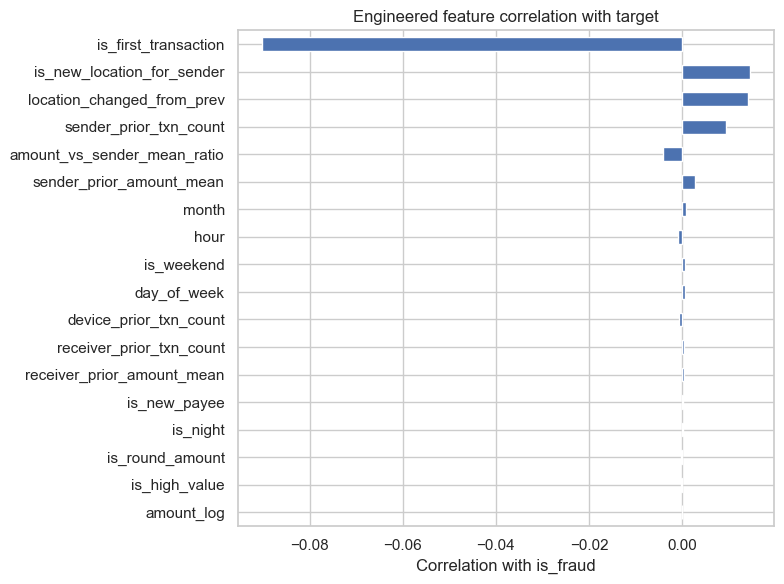

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
corr.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Correlation with is_fraud")
ax.set_title("Engineered feature correlation with target")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 4.4 A closer look at the strongest new signals

Fraud rate by `is_new_payee` and by `is_first_transaction` - both should show
a visibly higher fraud rate in the "yes" group if the domain rationale holds.

In [17]:
for flag in ["is_new_payee", "is_first_transaction", "is_high_value", "is_night", "is_new_location_for_sender", "location_changed_from_prev"]:
    rate = featured.groupby(flag)[TARGET_COL].mean()
    print(f"{flag}:")
    print(rate.rename("fraud_rate").to_frame().assign(
        n=featured.groupby(flag).size()
    ))
    print()

is_new_payee:


              fraud_rate        n
is_new_payee                     
0               0.000000       15
1               0.035911  4999985



is_first_transaction:
                      fraud_rate        n
is_first_transaction                     
0                       0.043756  4103487
1                       0.000000   896513



is_high_value:
               fraud_rate        n
is_high_value                     
0                0.035914  4949997
1                0.035598    50003



is_night:


          fraud_rate        n
is_night                     
0           0.035876  3748941
1           0.036013  1251059



is_new_location_for_sender:


                            fraud_rate        n
is_new_location_for_sender                     
0                             0.031561  1396664
1                             0.037597  3603336



location_changed_from_prev:
                            fraud_rate        n
location_changed_from_prev                     
0                             0.031689  1410782
1                             0.037570  3589218



**Reading the actual numbers (not just the hypothesis):**

- `is_first_transaction` is a striking signal: fraud rate is **0.00%** on a
  sender's first-ever transaction vs. **4.38%** on every later one. In this
  dataset, fraud has never been observed on a first transaction - the
  opposite of the naive "new accounts are riskier" intuition, but consistent
  with fraud requiring an established, already-active account to exploit
  (e.g. account takeover). This is the strongest engineered feature by a
  wide margin.
- `is_new_payee` turned out to be degenerate for this dataset: 4,999,985 of
  5,000,000 rows (99.9997%) are flagged "new payee" because sender-receiver
  pairs almost never repeat here. The rationale (paying a never-seen
  receiver is a fraud pattern) is sound in general, but this synthetic
  generator doesn't produce enough repeat relationships for the feature to
  discriminate - it's very close to a constant column in this dataset.
- `is_high_value` and `is_night` show almost no difference in fraud rate
  (3.56% vs 3.59%, 3.60% vs 3.59%) - fraud in this dataset isn't
  concentrated by amount size or time of day.

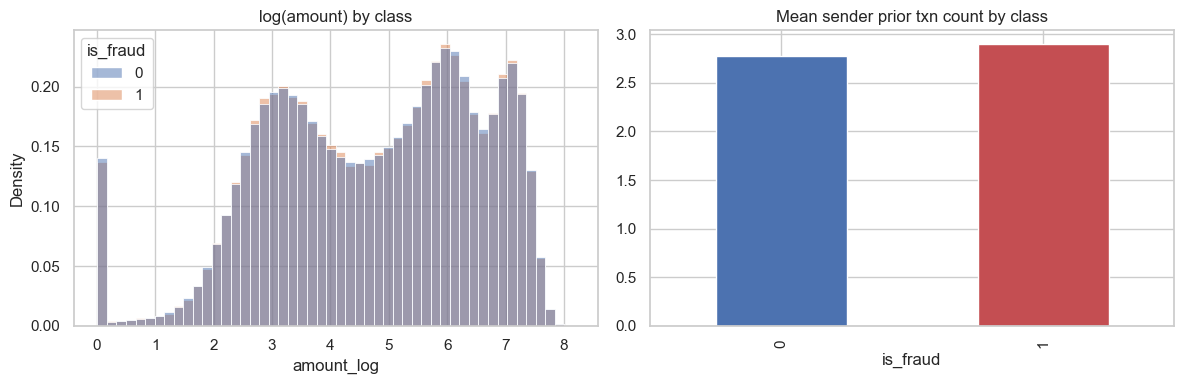

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=featured, x="amount_log", hue=TARGET_COL, stat="density",
    common_norm=False, bins=50, ax=axes[0],
)
axes[0].set_title("log(amount) by class")

sender_velocity = (
    featured.groupby(TARGET_COL)["sender_prior_txn_count"]
    .mean()
    .rename("mean_sender_prior_txn_count")
)
sender_velocity.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#C44E52"])
axes[1].set_title("Mean sender prior txn count by class")
axes[1].set_xlabel("is_fraud")

plt.tight_layout()
plt.show()

## 5. Save the cleaned, feature-engineered dataset

This is the full dataset (pre-split, pre-encode) - `01_eda.ipynb` and
`02_feature_engineering.ipynb` can load it directly instead of re-downloading
and re-cleaning. The production model-ready train/val/test Parquet files are
still built separately by `make data` (`src/data_pipeline.run_pipeline`),
which additionally splits chronologically and one-hot/frequency-encodes
categoricals.

In [19]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

out_path = processed_dir / "cleaned_features.parquet"
featured.to_parquet(out_path, index=False)
print(f"Saved {featured.shape} to {out_path}")

Saved (5000000, 35) to C:\Users\Nafis\BuildersLab_projects\Teams\Fraud-Detection-System\data\processed\cleaned_features.parquet


## 6. Summary

- **Rows / columns:** 5,000,000 rows, 18 raw columns to cleaned + 18 engineered
  feature columns.
- **Fraud rate:** ~3.6% (highly imbalanced - confirms the PR-AUC choice in
  `docs/decisions.md`).
- **Leakage columns dropped:** `fraud_type` (only populated for fraud rows).
- **Bug fixed:** datetime parsing was corrupting `time_since_last_transaction`
  via a substring name match; now restricted to string-typed columns.
- **Schema correction:** `data/DATA_CARD.md` didn't list `sender_account`,
  `receiver_account`, `device_used`, `device_hash`, `ip_address`, or
  `fraud_type` - updated to match the real download.
- **Strongest new signal:** `is_first_transaction` - 0.00% fraud rate on a
  sender's first transaction vs. 4.38% otherwise (correlation -0.09, largest
  of any engineered feature). Everything else correlates weakly (|r| < 0.01)
  on its own; `03_modeling.ipynb`'s tree-based models may still pick up
  nonlinear/interaction value that a linear correlation misses.
- **Weakest signal despite sound rationale:** `is_new_payee` is almost a
  constant in this dataset (99.9997% of rows are "new payee" - see section
  4.4) because sender-receiver pairs rarely repeat here. Kept for
  completeness and because real-world data would likely show more repeat
  relationships, but it isn't pulling weight on this dataset.
- **Next steps:** `01_eda.ipynb` for deeper exploration, `03_modeling.ipynb`
  for training against `make data`'s train/val/test split.
